# 01 — Model verification: governing equations, analytical results and stability theory

**Objective.** Check independently, by symbolic and exact numerical calculation, every
analytical statement used in the manuscript before any simulation is trusted:

1. the model, its units, time scales and dimensionless groups;
2. the forward-Euler/centred (FTCS) stencil and the sign of its advective coefficients;
3. the von Neumann amplification factor *including reaction*, the exact strict-stability
   region, and the modified equation;
4. the steady solution with Danckwerts boundary conditions and its PFR/CSTR limits;
5. the continuous and discrete energy and mass-balance identities that underpin the
   stability proof of the production scheme;
6. a reproduction of the stencil printed in the original manuscript, demonstrating the
   upstream-transport error.

**Model.** For concentration $C(x,t)$ [mol m$^{-3}$] in a reactor of length $L$:

$$
\partial_t C + u\,\partial_x C = D\,\partial_{xx} C - kC,\qquad 0<x<L,\ t>0,
$$
$$
uC(0,t) - D\,\partial_x C(0,t) = u\,C_\mathrm{in}(t),\qquad \partial_x C(L,t)=0,\qquad C(x,0)=C_0(x).
$$

with $u\ge 0$ [m s$^{-1}$], $D\ge0$ [m$^2$ s$^{-1}$], $k\ge 0$ [s$^{-1}$]. The reaction term $-kC$
is first-order **consumption**; no stoichiometric coefficient is needed for a single species.

In [1]:
# --- Environment set-up (no hidden state: every notebook starts here) -------
import sys
from pathlib import Path

try:
    import pfr_uq  # installed with `pip install -e .`
except ImportError:  # fall back to the repository's src/ directory
    root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
    sys.path.insert(0, str(root / "src"))
    import pfr_uq

import numpy as np
import pandas as pd
from pfr_uq import model, solvers, metrics, uncertainty, reporting, paths

np.set_printoptions(precision=6, suppress=False)
print("pfr_uq", pfr_uq.__version__, "| numpy", np.__version__, "| repository root:", paths.ROOT.name)

pfr_uq 1.0.0 | numpy 2.5.3 | repository root: Mohamed_AIMS_Project


In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from pfr_uq import legacy

SUMMARY = {}  # every quantity reported from this notebook
P = model.BASELINE
print(P)

ReactorParameters(L=1.0, u=0.1, D=0.01, k=0.1, C_in=1.0)


## 1. Parameters, time scales and dimensionless groups

The baseline parameters are **illustrative** (laboratory-scale tubular reactor with
substantial axial dispersion); they are not fitted to a particular experiment.
With $\xi=x/L$, $\vartheta = tu/L$ and $\phi = C/C_\mathrm{ref}$ the model becomes
$\partial_\vartheta\phi+\partial_\xi\phi=\mathrm{Pe}^{-1}\partial_{\xi\xi}\phi-\mathrm{Da}\,\phi$ with
$\mathrm{Pe}=uL/D=\tau_d/\tau_a$ and $\mathrm{Da}=kL/u=\tau_a/\tau_r$ (first Damköhler number for
first-order kinetics, based on the space time $\tau_a=L/u$).

In [3]:
# Symbolic nondimensionalisation check
x, t, L, u, D, k, Cref = sp.symbols("x t L u D k C_ref", positive=True)
Pe, Da = sp.symbols("Pe Da", positive=True)
# Chain rule with C = C_ref * phi(xi, vartheta), xi = x/L, vartheta = u t / L:
# d/dt = (u/L) d/dvartheta,  d/dx = (1/L) d/dxi
phi_v, phi_th, phi_xi, phi_xixi = sp.symbols("phi phi_vartheta phi_xi phi_xixi")
pde = Cref * (u / L) * phi_th + u * Cref / L * phi_xi - D * Cref / L**2 * phi_xixi + k * Cref * phi_v
scaled = sp.expand(sp.simplify(pde * L / (u * Cref)).subs({D: u * L / Pe, k: Da * u / L}))
print("(L / (u C_ref)) x [C_t + u C_x - D C_xx + k C] =", scaled)
assert sp.simplify(scaled - (phi_th + phi_xi - phi_xixi / Pe + Da * phi_v)) == 0

params = pd.DataFrame(
    [
        ["L", "reactor length", P.L, "m", "illustrative laboratory scale"],
        ["u", "mean axial velocity", P.u, "m s^-1", "illustrative"],
        ["D", "axial dispersion coefficient", P.D, "m^2 s^-1", "illustrative; gives Pe = 10 (strong back-mixing)"],
        ["k", "first-order rate constant", P.k, "s^-1", "illustrative; gives Da = 1"],
        ["C_in", "feed concentration", P.C_in, "mol m^-3", "reference scale"],
        ["tau_a", "space time L/u", P.tau_adv, "s", "derived"],
        ["tau_d", "dispersion time L^2/D", P.tau_disp, "s", "derived"],
        ["tau_r", "reaction time 1/k", P.tau_rxn, "s", "derived"],
        ["Pe", "Peclet number uL/D", P.Pe, "-", "derived"],
        ["Da", "Damkohler number kL/u", P.Da, "-", "derived"],
    ],
    columns=["symbol", "definition", "value", "unit", "rationale"],
)
params.to_csv(paths.TABLES / "parameters.csv", index=False)
SUMMARY["baseline"] = dict(L=P.L, u=P.u, D=P.D, k=P.k, C_in=P.C_in, Pe=P.Pe, Da=P.Da,
                           tau_a=P.tau_adv, tau_d=P.tau_disp, tau_r=P.tau_rxn)
params

(L / (u C_ref)) x [C_t + u C_x - D C_xx + k C] = Da*phi + phi_vartheta + phi_xi - phi_xixi/Pe


,symbol,definition,value,unit,rationale
0,L,reactor length,1.00,m,illustrative laboratory scale
1,u,mean axial velocity,0.10,m s^-1,illustrative
2,D,axial dispersion coefficient,0.01,m^2 s^-1,illustrative; gives Pe = 10 (strong back-mixing)
3,k,first-order rate constant,0.10,s^-1,illustrative; gives Da = 1
4,C_in,feed concentration,1.00,mol m^-3,reference scale
5,tau_a,space time L/u,10.00,s,derived
6,tau_d,dispersion time L^2/D,100.00,s,derived
7,tau_r,reaction time 1/k,10.00,s,derived
8,Pe,Peclet number uL/D,10.00,-,derived
9,Da,Damkohler number kL/u,1.00,-,derived


**Dimensional check.** $[\partial_t C]=[u\partial_xC]=[D\partial_{xx}C]=[kC]=$ mol m$^{-3}$ s$^{-1}$;
both boundary conditions have units of a molar flux density, mol m$^{-2}$ s$^{-1}$. The printed
operator above is $\partial_\vartheta\phi+\partial_\xi\phi-\mathrm{Pe}^{-1}\partial_{\xi\xi}\phi+\mathrm{Da}\,\phi$,
confirming the dimensionless form.

## 2. The FTCS stencil: sign of the advective coefficients

Forward Euler in time with centred differences gives
$C_i^{n+1}=C_i^n+\Delta t\left[-u\frac{C_{i+1}^n-C_{i-1}^n}{2h}+D\frac{C_{i+1}^n-2C_i^n+C_{i-1}^n}{h^2}-kC_i^n\right]$.
With $\alpha=D\Delta t/h^2$, $\beta=u\Delta t/h$, $\kappa=k\Delta t$ we collect coefficients symbolically.

In [4]:
h, dt = sp.symbols("h Delta_t", positive=True)
alpha, beta, kappa = sp.symbols("alpha beta kappa", nonnegative=True)
Cm, C0, Cp = sp.symbols("C_{i-1} C_i C_{i+1}")
update = C0 + dt * (-u * (Cp - Cm) / (2 * h) + D * (Cp - 2 * C0 + Cm) / h**2 - k * C0)
update = sp.expand(update.subs({D: alpha * h**2 / dt, u: beta * h / dt, k: kappa / dt}))
coef = {name: sp.factor(update.coeff(sym)) for name, sym in [("C_{i-1}", Cm), ("C_i", C0), ("C_{i+1}", Cp)]}
for name, c in coef.items():
    print(f"coefficient of {name:8s}: {c}")

printed = {"C_{i-1}": alpha - beta / 2, "C_i": 1 - 2 * alpha, "C_{i+1}": alpha + beta / 2}
print("\nOriginal manuscript (printed):", printed)
swap = {name: sp.simplify(printed[name].subs(beta, -beta)) for name in printed}
print("Printed stencil with beta -> -beta:", swap)
assert sp.simplify(coef["C_{i-1}"] - (alpha + beta / 2)) == 0
assert sp.simplify(coef["C_{i+1}"] - (alpha - beta / 2)) == 0
SUMMARY["stencil"] = {k_: str(v) for k_, v in coef.items()}

coefficient of C_{i-1} : (2*alpha + beta)/2
coefficient of C_i     : -2*alpha - kappa + 1
coefficient of C_{i+1} : (2*alpha - beta)/2

Original manuscript (printed): {'C_{i-1}': alpha - beta/2, 'C_i': 1 - 2*alpha, 'C_{i+1}': alpha + beta/2}
Printed stencil with beta -> -beta: {'C_{i-1}': alpha + beta/2, 'C_i': 1 - 2*alpha, 'C_{i+1}': alpha - beta/2}


The correct stencil is $(\alpha+\beta/2)C_{i-1}+(1-2\alpha-\kappa)C_i+(\alpha-\beta/2)C_{i+1}$: the upstream
neighbour $C_{i-1}$ receives the larger weight when $u>0$. The printed stencil equals the correct one
with $\beta\to-\beta$, i.e. it transports material **upstream** (velocity $-u$); it also omits the
reaction contribution $-\kappa$ from the central coefficient.

## 3. Von Neumann analysis with reaction

Inserting $C_j^n=g^n e^{\mathrm{i}j\theta}$ gives $g(\theta)=1-\kappa-2\alpha(1-\cos\theta)-\mathrm{i}\beta\sin\theta$.
With $w=1-\cos\theta\in[0,2]$, $|g|^2-1=P(w)=(4\alpha^2-\beta^2)w^2+(2\beta^2-4\alpha(1-\kappa))w+(1-\kappa)^2-1$.

In [5]:
theta_, w = sp.symbols("theta w", real=True)
g = 1 - kappa + alpha * (sp.exp(-sp.I * theta_) - 2 + sp.exp(sp.I * theta_)) + beta / 2 * (sp.exp(-sp.I * theta_) - sp.exp(sp.I * theta_))
g_simpl = sp.simplify(sp.expand_complex(g.rewrite(sp.cos)))
print("g(theta) =", g_simpl)
mod2 = sp.expand(sp.re(g_simpl) ** 2 + sp.im(g_simpl) ** 2)
P_w = sp.expand(mod2.subs(sp.sin(theta_) ** 2, w * (2 - w)).subs(sp.cos(theta_), 1 - w) - 1)
P_w = sp.collect(sp.expand(P_w.subs(sp.sin(theta_)**2, w*(2-w))), w)
print("|g|^2 - 1 = P(w) =", P_w)
P_expected = (4*alpha**2 - beta**2)*w**2 + (2*beta**2 - 4*alpha*(1-kappa))*w + (1-kappa)**2 - 1
assert sp.simplify(P_w - P_expected) == 0

# Special cases
print("pure advection (alpha=kappa=0): |g|^2 - 1 =", sp.factor(P_expected.subs({alpha: 0, kappa: 0})), " > 0 for 0<w<2")
print("advection-reaction (alpha=0): max_w P =", sp.simplify(P_expected.subs({alpha: 0}).subs(w, 1)), "-> stable iff beta^2 <= kappa(2-kappa)")
print("P(2) =", sp.factor(P_expected.subs(w, 2)), "-> requires 4 alpha + kappa <= 2")
print("dP/dw at w=0 with kappa=0:", sp.diff(P_expected, w).subs({w: 0, kappa: 0}), "-> requires beta^2 <= 2 alpha")

g(theta) = 2*alpha*(cos(theta) - 1) - I*beta*sin(theta) - kappa + 1
|g|^2 - 1 = P(w) = kappa**2 - 2*kappa + w**2*(4*alpha**2 - beta**2) + w*(4*alpha*kappa - 4*alpha + 2*beta**2)
pure advection (alpha=kappa=0): |g|^2 - 1 = -beta**2*w*(w - 2)  > 0 for 0<w<2
advection-reaction (alpha=0): max_w P = beta**2 + (kappa - 1)**2 - 1 -> stable iff beta^2 <= kappa(2-kappa)


P(2) = (4*alpha + kappa)*(4*alpha + kappa - 2) -> requires 4 alpha + kappa <= 2
dP/dw at w=0 with kappa=0: -4*alpha + 2*beta**2 -> requires beta^2 <= 2 alpha


Consequences (all verified numerically below):

* **Pure advection** ($\alpha=\kappa=0$): $|g|^2=1+\beta^2\sin^2\theta>1$ for every $\beta\neq0$ — centred FTCS is
  unconditionally unstable; a CFL bound $|\beta|\le1$ does **not** stabilise it.
* **No reaction** ($\kappa=0$): $|g|\le1$ for all $\theta$ iff $\beta^2\le 2\alpha\le1$, i.e.
  $\Delta t\le\min\{h^2/(2D),\,2D/u^2\}$. ($|\beta|\le1$ is then implied.)
* **With reaction**: the exact region is $\max_{w\in[0,2]}P(w)\le0$ (end points and vertex), implemented in
  `solvers.ftcs_strictly_stable`. Reaction enlarges the region slightly near $w=0$ (it damps all modes) but
  also enters $4\alpha+\kappa\le2$.
* **Lax–Richtmyer stability** under refinement at fixed $\alpha$ only requires $\alpha\le1/2$, because
  $\beta^2=u^2\alpha\Delta t/D=O(\Delta t)$; the strict condition is the practical *no-growth* condition.
* **Positivity** (all stencil weights $\ge0$): $|\beta|\le2\alpha$ (cell Péclet number $uh/D\le2$) and $2\alpha+\kappa\le1$.

In [6]:
rng = np.random.default_rng(20261002)
n = 20000
a_s = rng.uniform(0, 0.7, n); b_s = rng.uniform(-1.3, 1.3, n); k_s = rng.uniform(0, 0.6, n)
analytic = solvers.ftcs_strictly_stable(a_s, b_s, k_s)
numeric_max = solvers.ftcs_max_amplification(a_s, b_s, k_s, n_theta=20001)
numeric = numeric_max <= 1 + 1e-9
disagree = analytic != numeric
print(f"random (alpha,beta,kappa) samples: {n}; disagreements: {disagree.sum()}")
print("max | |g|max - 1 | over disagreements:", np.abs(numeric_max[disagree] - 1).max() if disagree.any() else 0.0)
# kappa = 0 closed form
k0 = solvers.ftcs_strictly_stable(a_s, b_s, 0.0)
closed = (b_s**2 <= 2 * a_s + 1e-12) & (2 * a_s <= 1 + 1e-12)
print("kappa=0: analytic test == (beta^2 <= 2 alpha <= 1) for all samples:", bool(np.all(k0 == closed)))
SUMMARY["ftcs_region_check"] = {"samples": n, "disagreements": int(disagree.sum()),
                                "max_dev_disagreements": float(np.abs(numeric_max[disagree] - 1).max()) if disagree.any() else 0.0,
                                "kappa0_closed_form_agrees": bool(np.all(k0 == closed))}

# Grid of max|g| for the stability-region figure (kappa = 0 and kappa = 0.1)
A_grid = np.linspace(0, 0.6, 241); B_grid = np.linspace(0, 1.2, 241)
AA, BB = np.meshgrid(A_grid, B_grid)
region = {}
for kap in (0.0, 0.1):
    region[kap] = {"gmax": solvers.ftcs_max_amplification(AA, BB, kap, n_theta=721),
                   "stable": solvers.ftcs_strictly_stable(AA, BB, kap)}
np.savez_compressed(paths.DATA / "ftcs_stability_region.npz", alpha=A_grid, beta=B_grid,
                    gmax_k0=region[0.0]["gmax"], stable_k0=region[0.0]["stable"],
                    gmax_k01=region[0.1]["gmax"], stable_k01=region[0.1]["stable"])
print("saved stability-region grids")

random (alpha,beta,kappa) samples: 20000; disagreements: 0
max | |g|max - 1 | over disagreements: 0.0
kappa=0: analytic test == (beta^2 <= 2 alpha <= 1) for all samples: True


saved stability-region grids


The few disagreements lie within $10^{-9}$ of the stability boundary (finite $\theta$ sampling), confirming
the analytic criterion.

### Modified equation of FTCS

Taylor-expanding the scheme about $(x_i,t_n)$ and eliminating $\partial_{tt}C$ with the PDE shows that FTCS
solves, to leading order, an equation with effective dispersion $D_\mathrm{eff}=D-u^2\Delta t/2+O(\Delta t\,kD,\,h^2)$.
The strict condition $\beta^2\le2\alpha$ is exactly $D_\mathrm{eff}\ge0$ at leading order: pure advection
($D=0$) is solved with **negative** diffusion. (The term $\tfrac{uh^2}{6}(1-\beta^2)\partial_{xxx}C$ printed in
the original manuscript is the Lax–Wendroff modified equation, not that of FTCS.)

In [7]:
X, T = sp.symbols("X T", real=True)
c = sp.Function("c")
# Truncation operator of the FTCS scheme applied to a smooth function, expanded in h and dt
def shift(expr, ax, d, order):
    return sum(sp.diff(expr, ax, m) * d**m / sp.factorial(m) for m in range(order + 1))
cf = c(X, T)
lhs = (shift(cf, T, dt, 3) - cf) / dt
rhs = -u * (shift(cf, X, h, 4) - shift(cf, X, -h, 4)) / (2 * h) + D * (shift(cf, X, h, 5) - 2 * cf + shift(cf, X, -h, 5)) / h**2 - k * cf
tau = sp.expand(lhs - rhs)   # = c_t + u c_x - D c_xx + k c + (dt/2) c_tt + O(dt^2, h^2)
lead = sp.expand(tau.subs({dt: 0, h: 0}))
first_dt = sp.expand(sp.diff(tau, dt).subs({dt: 0, h: 0}))
print("leading part      :", lead)
print("O(dt) coefficient :", first_dt)
# Replace c_tt using the PDE: c_tt = (-u d_x + D d_xx - k)^2 c
L_op = lambda f: -u * sp.diff(f, X) + D * sp.diff(f, X, 2) - k * f
ctt = sp.expand(L_op(L_op(cf)))
dt_term = sp.expand(first_dt.subs(sp.Derivative(cf, (T, 2)), ctt))
print("O(dt) term after eliminating c_tt:")
sp.pprint(sp.collect(dt_term, [sp.Derivative(cf, (X, 2)), sp.Derivative(cf, X), cf]))
coef_cxx = sp.expand(dt_term).coeff(sp.Derivative(cf, (X, 2)))
print("coefficient of c_xx in (dt * ...):", sp.simplify(coef_cxx), " -> D_eff = D - dt*(u^2/2 - k D)")

leading part      : -D*Derivative(c(X, T), (X, 2)) + k*c(X, T) + u*Derivative(c(X, T), X) + Derivative(c(X, T), T)
O(dt) coefficient : Derivative(c(X, T), (T, 2))/2
O(dt) term after eliminating c_tt:
    4                                                                          ↪
 2 ∂                                                                           ↪
D ⋅───(c(X, T))                                                                ↪
     4                 3              2                             ⎛        2 ↪
   ∂X                 ∂              k ⋅c(X, T)       ∂             ⎜       u  ↪
─────────────── - D⋅u⋅───(c(X, T)) + ────────── + k⋅u⋅──(c(X, T)) + ⎜-D⋅k + ── ↪
       2                3                2            ∂X            ⎝       2  ↪
                      ∂X                                                       ↪

↪               
↪               
↪               
↪ ⎞  2          
↪ ⎟ ∂           
↪ ⎟⋅───(c(X, T))
↪ ⎠   2         
↪   ∂X          
coefficient of 

## 4. Steady state with Danckwerts conditions

At steady state, $\phi''/\mathrm{Pe}-\phi'-\mathrm{Da}\,\phi=0$, $\phi(0)-\phi'(0)/\mathrm{Pe}=1$, $\phi'(1)=0$.
Characteristic roots $m_\pm=\tfrac{\mathrm{Pe}}{2}(1\pm q)$, $q=\sqrt{1+4\mathrm{Da}/\mathrm{Pe}}$
(dimensional: $\lambda_\pm=(u\pm\sqrt{u^2+4kD})/(2D)$). The outlet value is the Wehner–Wilhelm result
$$\frac{C(L)}{C_\mathrm{in}}=\frac{4q\,e^{\mathrm{Pe}/2}}{(1+q)^2e^{q\mathrm{Pe}/2}-(1-q)^2e^{-q\mathrm{Pe}/2}}.$$

In [8]:
xs = sp.symbols("xi", nonnegative=True)
q = sp.sqrt(1 + 4 * Da / Pe)
mp, mm = Pe * (1 + q) / 2, Pe * (1 - q) / 2
A_, B_ = sp.symbols("A B")
phi_s = A_ * sp.exp(mp * xs) + B_ * sp.exp(mm * xs)
assert sp.simplify(sp.diff(phi_s, xs, 2) / Pe - sp.diff(phi_s, xs) - Da * phi_s) == 0
sol = sp.solve([(phi_s - sp.diff(phi_s, xs) / Pe).subs(xs, 0) - 1, sp.diff(phi_s, xs).subs(xs, 1)], [A_, B_], dict=True)[0]
phi_sol = phi_s.subs(sol)
ww = 4 * q * sp.exp(Pe / 2) / ((1 + q) ** 2 * sp.exp(q * Pe / 2) - (1 - q) ** 2 * sp.exp(-q * Pe / 2))
checks = []
for pe_v, da_v in [(0.5, 0.2), (10, 1), (40, 3), (200, 0.5)]:
    sym_out = float(phi_sol.subs({Pe: pe_v, Da: da_v, xs: 1}).evalf(30))
    ww_v = float(ww.subs({Pe: pe_v, Da: da_v}).evalf(30))
    code_v = float(model.danckwerts_outlet_ratio(pe_v, da_v))
    prof_v = model.danckwerts_profile(np.linspace(0, 1, 5), pe_v, da_v)
    prof_s = [float(phi_sol.subs({Pe: pe_v, Da: da_v, xs: z}).evalf(30)) for z in np.linspace(0, 1, 5)]
    checks.append([pe_v, da_v, sym_out, ww_v, code_v, np.max(np.abs(prof_v - prof_s))])
chk = pd.DataFrame(checks, columns=["Pe", "Da", "symbolic phi(1)", "Wehner-Wilhelm", "code", "max profile diff"])
print(chk.to_string(index=False))
assert np.allclose(chk["symbolic phi(1)"], chk["code"], rtol=1e-12)
SUMMARY["steady_baseline_outlet_ratio"] = float(model.danckwerts_outlet_ratio(P.Pe, P.Da))
SUMMARY["steady_baseline_conversion"] = 1 - SUMMARY["steady_baseline_outlet_ratio"]
SUMMARY["pfr_baseline_conversion"] = float(1 - np.exp(-P.Da))
SUMMARY["cstr_baseline_conversion"] = float(P.Da / (1 + P.Da))
print("\nBaseline (Pe=10, Da=1): C(L)/C_in =", SUMMARY["steady_baseline_outlet_ratio"],
      "conversion X =", SUMMARY["steady_baseline_conversion"])
print("Ideal PFR conversion 1-exp(-Da) =", SUMMARY["pfr_baseline_conversion"], "; CSTR Da/(1+Da) =", SUMMARY["cstr_baseline_conversion"])

   Pe  Da  symbolic phi(1)  Wehner-Wilhelm     code  max profile diff
  0.5 0.2         0.831276        0.831276 0.831276      2.220446e-16
 10.0 1.0         0.397267        0.397267 0.397267      1.110223e-16
 40.0 3.0         0.060337        0.060337 0.060337      2.220446e-16
200.0 0.5         0.607282        0.607282 0.607282      4.087175e-12

Baseline (Pe=10, Da=1): C(L)/C_in = 0.3972667733061267 conversion X = 0.6027332266938733
Ideal PFR conversion 1-exp(-Da) = 0.6321205588285577 ; CSTR Da/(1+Da) = 0.5


In [9]:
# Limits: Pe -> infinity (ideal PFR) and Pe -> 0 (CSTR)
for da_v in (0.5, 1.0, 3.0):
    big = [float(model.danckwerts_outlet_ratio(pe_v, da_v)) for pe_v in (1e2, 1e3, 1e4)]
    small = [float(model.danckwerts_outlet_ratio(pe_v, da_v)) for pe_v in (1e-1, 1e-2, 1e-3)]
    print(f"Da={da_v}: Pe=1e2,1e3,1e4 -> {np.round(big, 6)}  exp(-Da)={np.exp(-da_v):.6f} | "
          f"Pe=1e-1,1e-2,1e-3 -> {np.round(small, 6)}  1/(1+Da)={1/(1+da_v):.6f}")

Da=0.5: Pe=1e2,1e3,1e4 -> [0.608019 0.606682 0.606546]  exp(-Da)=0.606531 | Pe=1e-1,1e-2,1e-3 -> [0.664861 0.666482 0.666648]  1/(1+Da)=0.666667
Da=1.0: Pe=1e2,1e3,1e4 -> [0.371468 0.368246 0.367916]  exp(-Da)=0.367879 | Pe=1e-1,1e-2,1e-3 -> [0.495948 0.499585 0.499958]  1/(1+Da)=0.500000
Da=3.0: Pe=1e2,1e3,1e4 -> [0.054159 0.050234 0.049832]  exp(-Da)=0.049787 | Pe=1e-1,1e-2,1e-3 -> [0.24105  0.249067 0.249906]  1/(1+Da)=0.250000


### The steady formula printed in the original manuscript

The original manuscript gave $C(x)=C_0\,[\lambda_+e^{\lambda_+(L-x)}-\lambda_-e^{\lambda_-(L-x)}]/[\lambda_+e^{\lambda_+L}-\lambda_-e^{\lambda_-L}]$
for a Dirichlet inlet and zero-gradient outlet. We test it with the consumption roots.

In [10]:
xx, LL = sp.symbols("x L", positive=True)
lam_p = (u + sp.sqrt(u**2 + 4 * k * D)) / (2 * D)
lam_m = (u - sp.sqrt(u**2 + 4 * k * D)) / (2 * D)
C_orig = (lam_p * sp.exp(lam_p * (LL - xx)) - lam_m * sp.exp(lam_m * (LL - xx))) / (lam_p * sp.exp(lam_p * LL) - lam_m * sp.exp(lam_m * LL))
vals = {u: P.u, D: P.D, k: P.k, LL: P.L}
ode_res = (D * sp.diff(C_orig, xx, 2) - u * sp.diff(C_orig, xx) - k * C_orig).subs(vals)
res_pts = [float(ode_res.subs(xx, z)) for z in (0.0, 0.3, 0.7, 1.0)]
dCdx_L = float(sp.diff(C_orig, xx).subs(vals).subs(xx, P.L))
# Correct Dirichlet-inlet solution for comparison
A2, B2 = sp.symbols("A2 B2")
C_dir = A2 * sp.exp(lam_p * xx) + B2 * sp.exp(lam_m * xx)
s2 = sp.solve([C_dir.subs(xx, 0) - 1, sp.diff(C_dir, xx).subs(xx, LL)], [A2, B2], dict=True)[0]
C_dir = C_dir.subs(s2)
res_dir = float((D * sp.diff(C_dir, xx, 2) - u * sp.diff(C_dir, xx) - k * C_dir).subs(vals).subs(xx, 0.3))
print("Original formula: ODE residual at x = 0, 0.3, 0.7, 1:", np.round(res_pts, 5), "; C'(L) =", f"{dCdx_L:.3e}")
print("Correct Dirichlet-inlet solution: ODE residual at x=0.3:", f"{res_dir:.1e}")
SUMMARY["original_steady_formula"] = {"ode_residual_x0.3": res_pts[1], "dCdx_at_L": dCdx_L}

Original formula: ODE residual at x = 0, 0.3, 0.7, 1: [2.18321e+00 8.25800e-02 1.05000e-03 4.00000e-05] ; C'(L) = -1.969e-04
Correct Dirichlet-inlet solution: ODE residual at x=0.3: -6.6e-18


The printed expression does not satisfy the ODE (the exponents $\lambda_\pm(L-x)$ correspond to the
reflected operator) nor the outlet condition. It has been replaced by the Danckwerts solution above.

## 5. Energy and mass identities

**Continuous.** Multiplying the PDE by $C$ and integrating, using both Danckwerts conditions,
$$\tfrac12\tfrac{d}{dt}\|C\|^2=-\tfrac u2C(L)^2-\tfrac u2C(0)^2+uC(0)C_\mathrm{in}-D\|C_x\|^2-k\|C\|^2
\le\tfrac u2C_\mathrm{in}^2-\tfrac u2C(L)^2-D\|C_x\|^2-k\|C\|^2,$$
and integrating the PDE gives the reactor mass balance $\tfrac{d}{dt}\int_0^LC\,dx=uC_\mathrm{in}-uC(L)-k\int_0^LC\,dx$.

**Discrete (finite volume, central or upwind advection).** For the homogeneous problem ($C_\mathrm{in}=0$),
$$h\,\mathbf C^\top A\mathbf C=-\tfrac u2C_0^2-\tfrac u2C_{N-1}^2-\tfrac Dh\sum_j(C_{j+1}-C_j)^2-kh\sum_jC_j^2\;\Big[-\tfrac u2\sum_j(C_{j+1}-C_j)^2\ \text{for upwind}\Big]\le0,$$
so $A+A^\top\preceq0$ and the Crank–Nicolson and backward-Euler maps are contractions in the discrete $L^2$ norm
for **every** $h$ and $\Delta t$. We verify the identity to round-off for random vectors.

In [11]:
rows = []
for adv in ("central", "upwind"):
    for (uu, DD, kk) in [(0.1, 0.01, 0.1), (1.0, 1e-4, 0.0), (0.1, 0.0, 0.3), (0.0, 0.02, 0.05)]:
        op = solvers.FVOperator(uu, DD, kk, 1.0, 50, advection=adv)
        hh = op.grid.h
        v = rng.standard_normal(op.N)
        lhs = hh * v @ (op.A @ v)
        dv = np.diff(v)
        rhs = -uu / 2 * v[0] ** 2 - uu / 2 * v[-1] ** 2 - DD / hh * np.sum(dv**2) - kk * hh * np.sum(v**2)
        if adv == "upwind":
            rhs -= uu / 2 * np.sum(dv**2)
        rows.append([adv, uu, DD, kk, lhs, rhs, abs(lhs - rhs), op.energy_matrix_max_eig()])
energy = pd.DataFrame(rows, columns=["advection", "u", "D", "k", "h C^T A C", "identity", "|diff|", "max eig sym(A)"])
print(energy.to_string(index=False))
assert energy["|diff|"].max() < 1e-12 and energy["max eig sym(A)"].max() <= 1e-12
SUMMARY["discrete_energy_identity_max_diff"] = float(energy["|diff|"].max())
SUMMARY["max_eig_sym_A"] = float(energy["max eig sym(A)"].max())

advection   u      D    k   h C^T A C    identity       |diff|  max eig sym(A)
  central 0.1 0.0100 0.10  -50.196863  -50.196863 1.421085e-14       -0.153502
  central 1.0 0.0001 0.00   -0.666298   -0.666298 4.440892e-16       -0.001026
  central 0.1 0.0000 0.30   -0.305004   -0.305004 0.000000e+00       -0.300000
  central 0.0 0.0200 0.05 -132.714731 -132.714731 2.842171e-14       -0.050000
   upwind 0.1 0.0100 0.10  -27.419159  -27.419159 0.000000e+00       -0.155997
   upwind 1.0 0.0001 0.00  -42.352019  -42.352019 7.105427e-15       -0.095707
   upwind 0.1 0.0000 0.30   -5.349064   -5.349064 8.881784e-16       -0.309483
   upwind 0.0 0.0200 0.05  -62.646262  -62.646262 7.105427e-15       -0.050000


In [12]:
# Crank--Nicolson amplification matrix: 2-norm <= 1 on the finite domain (non-normal operator)
norms = []
for adv in ("central", "upwind"):
    for dtv in (0.01, 0.1, 1.0, 10.0):
        op = solvers.FVOperator(P.u, 1e-4, 0.0, 1.0, 80, advection=adv)  # cell Peclet number u h / D = 12.5
        Ad = op.A.toarray(); I = np.eye(op.N)
        R = np.linalg.solve(I - 0.5 * dtv * Ad, I + 0.5 * dtv * Ad)
        norms.append([adv, dtv, np.linalg.norm(R, 2), max(abs(np.linalg.eigvals(R)))])
cn = pd.DataFrame(norms, columns=["advection", "dt", "||R_CN||_2", "spectral radius"])
print(cn.to_string(index=False))
assert cn["||R_CN||_2"].max() <= 1 + 1e-12
SUMMARY["cn_matrix_norm_max"] = float(cn["||R_CN||_2"].max())

advection    dt  ||R_CN||_2  spectral radius
  central  0.01    0.999990         0.987300
  central  0.10    0.999900         0.895089
  central  1.00    0.999021         0.927231
  central 10.00    0.997123         0.992024
   upwind  0.01    0.999931         0.973947
   upwind  0.10    0.999308         0.761858
   upwind  1.00    0.993256         0.775774
   upwind 10.00    0.979733         0.975328


## 6. Reproducing the original stencil error

We run the stencil exactly as printed (node grid, Dirichlet inlet $C=0$, one-sided zero-gradient outlet) and
the corrected stencil, from a Gaussian pulse centred at $x=0.5$ m, with $u=0.1$ m s$^{-1}$, $D=10^{-3}$ m$^2$ s$^{-1}$,
$k=0$, $h=0.005$ m, $\Delta t=10^{-3}$ s (so $\alpha=0.04$, $\beta=0.02$; both stencils satisfy the
strict stability and positivity conditions). Physically the pulse centroid must move to $x=0.5+ut$.

In [13]:
gauss0 = lambda xv: np.exp(-((xv - 0.5) ** 2) / (2 * 0.05**2))
times = (0.0, 1.0, 2.0, 3.0)
legacy_runs = {}
for st in ("original", "corrected"):
    xn, snaps = legacy.node_ftcs(0.1, 1e-3, 0.0, 1.0, 200, 1e-3, 3.0, gauss0, save_times=times, stencil=st)
    legacy_runs[st] = snaps
rows = []
for tt in times:
    row = [tt, 0.5 + 0.1 * tt]
    for st in ("original", "corrected"):
        cc = legacy_runs[st][tt]
        row.append(np.sum(xn * cc) / np.sum(cc))
    rows.append(row)
direction = pd.DataFrame(rows, columns=["t [s]", "exact centroid [m]", "original stencil", "corrected stencil"])
print(direction.to_string(index=False))
pd.DataFrame({"x": xn, **{f"{st}_t{tt:g}": legacy_runs[st][tt] for st in legacy_runs for tt in times}}).to_csv(
    paths.DATA / "legacy_direction_profiles.csv", index=False)
direction.to_csv(paths.DATA / "legacy_direction_centroids.csv", index=False)
SUMMARY["legacy_centroid_t3"] = {"exact": 0.8, "original": float(direction.iloc[-1, 2]), "corrected": float(direction.iloc[-1, 3])}

 t [s]  exact centroid [m]  original stencil  corrected stencil
   0.0                 0.5          0.500000           0.500000
   1.0                 0.6          0.400000           0.600000
   2.0                 0.7          0.300044           0.699975
   3.0                 0.8          0.204235           0.796834


The printed stencil moves the pulse to $x\approx0.2$ m at $t=3$ s instead of $0.8$ m — exactly the behaviour visible
in panel (a) of the original Figure 2. All results built on that stencil (original Figures 2–7 and the
breakthrough statistics) are therefore not reproducible and have been discarded.

## 7. Explicit FTCS on the finite domain: demonstrations

All runs use the cell-centred finite-volume operator with Danckwerts conditions, $h=1/200$ m, and a rectangular
pulse ($C=1$ on $0.2\le x\le0.4$ m, cell averages), whose broad Fourier spectrum excites every wavenumber:

* (i) pure advection, $u=0.1$ m s$^{-1}$, $D=k=0$, $\beta=0.4$ (inside the CFL bound $|\beta|\le1$);
* (ii) advection–dispersion with $\alpha=0.25\le1/2$ and $\beta=0.8$ (so $|\beta|\le1$ but $\beta^2>2\alpha$);
* Crank–Nicolson with the same $\Delta t$ for comparison.

In [14]:
N_demo = 200
grid_demo = solvers.Grid(1.0, N_demo)
h_demo = grid_demo.h
rect = metrics.cell_average(lambda xv: ((xv >= 0.2) & (xv <= 0.4)).astype(float), grid_demo.faces, n_gauss=64)

def norm_history(op, C0, dt_, n_, theta_):
    """Discrete L2 norm after every step (one step at a time so every profile is available)."""
    hist = [metrics.norm_l2(C0, op.grid.h)]
    C = C0.copy()
    for _ in range(n_):
        C = solvers.integrate(op, C, dt_, dt_, theta=theta_, stability="ignore").final[0]
        hist.append(metrics.norm_l2(C, op.grid.h))
    return np.array(hist), C

# (i) pure advection
u_i = 0.1; dt_i = 0.4 * h_demo / u_i; n_i = 300
op_i = solvers.FVOperator(u_i, 0.0, 0.0, 1.0, N_demo)
hist_i, C_i = norm_history(op_i, rect, dt_i, n_i, 0.0)
hist_i_cn, C_i_cn = norm_history(op_i, rect, dt_i, n_i, 0.5)
# (ii) alpha = 0.25, beta = 0.8  ->  D = u h beta... : dt = 0.25 h^2 / D and beta = u dt / h = 0.25 u h / D
u_ii = 0.1; D_ii = 0.25 * u_ii * h_demo / 0.8; dt_ii = 0.25 * h_demo**2 / D_ii; n_ii = 150
a_ii, b_ii, _ = solvers.explicit_numbers(u_ii, D_ii, 0.0, h_demo, dt_ii)
op_ii = solvers.FVOperator(u_ii, D_ii, 0.0, 1.0, N_demo)
hist_ii, C_ii = norm_history(op_ii, rect, dt_ii, n_ii, 0.0)
hist_ii_cn, C_ii_cn = norm_history(op_ii, rect, dt_ii, n_ii, 0.5)

def finite_domain_radius(op, dt_):
    M = np.eye(op.N) + dt_ * op.A.toarray()
    return max(abs(np.linalg.eigvals(M)))

rows = [
    ["(i) pure advection", 0.0, 0.4, float(solvers.ftcs_max_amplification(0.0, 0.4, 0.0)), finite_domain_radius(op_i, dt_i),
     n_i, hist_i[-1] / hist_i[0], hist_i_cn[-1] / hist_i_cn[0], C_i.min(), C_i_cn.min()],
    ["(ii) adv.-dispersion", a_ii, b_ii, float(solvers.ftcs_max_amplification(a_ii, b_ii, 0.0)), finite_domain_radius(op_ii, dt_ii),
     n_ii, hist_ii[-1] / hist_ii[0], hist_ii_cn[-1] / hist_ii_cn[0], C_ii.min(), C_ii_cn.min()],
]
demo_tab = pd.DataFrame(rows, columns=["case", "alpha", "beta", "von Neumann max|g|", "finite-domain spectral radius",
                                       "steps", "FTCS ||C^n||/||C^0||", "CN ||C^n||/||C^0||", "FTCS min C", "CN min C"])
print(demo_tab.to_string(index=False))
pd.DataFrame({"step": np.arange(n_i + 1), "ftcs": hist_i, "cn": hist_i_cn}).to_csv(paths.DATA / "ftcs_growth_pure_advection.csv", index=False)
pd.DataFrame({"step": np.arange(n_ii + 1), "ftcs": hist_ii, "cn": hist_ii_cn}).to_csv(paths.DATA / "ftcs_growth_adv_disp.csv", index=False)
SUMMARY["ftcs_demo"] = demo_tab.set_index("case").to_dict(orient="index")

                case  alpha  beta  von Neumann max|g|  finite-domain spectral radius  steps  FTCS ||C^n||/||C^0||  CN ||C^n||/||C^0||    FTCS min C  CN min C
  (i) pure advection   0.00   0.4            1.077033                       1.077014    300          2.202602e+08            0.995604 -2.646478e+08 -0.339862
(ii) adv.-dispersion   0.25   0.8            1.024820                       0.925839    150          3.691882e+00            0.855571 -4.980261e+00 -0.000006


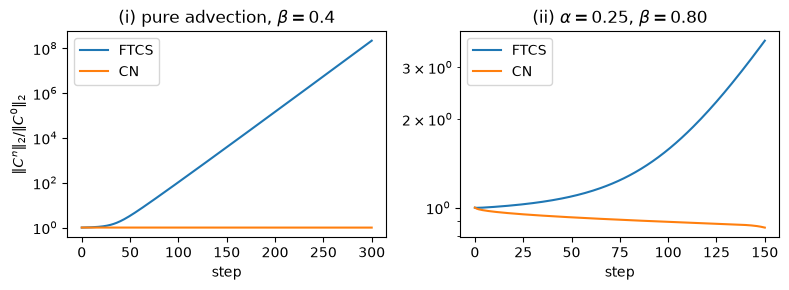

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].semilogy(hist_i / hist_i[0], label="FTCS"); ax[0].semilogy(hist_i_cn / hist_i_cn[0], label="CN")
ax[0].set(xlabel="step", ylabel=r"$\|C^n\|_2/\|C^0\|_2$", title=r"(i) pure advection, $\beta=0.4$"); ax[0].legend()
ax[1].semilogy(hist_ii / hist_ii[0], label="FTCS"); ax[1].semilogy(hist_ii_cn / hist_ii_cn[0], label="CN")
ax[1].set(xlabel="step", title=rf"(ii) $\alpha={a_ii:.2f}$, $\beta={b_ii:.2f}$"); ax[1].legend()
plt.tight_layout(); plt.show()

In both cases FTCS amplifies the solution although $|\beta|\le1$, as predicted ($\max|g|>1$). On the finite domain
the unstable modes are partly advected out of the outlet, so the spectral radius of the iteration matrix can be
below one while the solution still grows by orders of magnitude over the simulated interval (non-normal transient
growth); the von Neumann condition is the relevant practical criterion. Crank–Nicolson never increases the
discrete $L^2$ norm, but it is not positivity preserving: with a discontinuous pulse and cell Péclet number
$uh/D>2$ it produces undershoots, which is why the production runs use smooth inlet data and resolve the cell
Péclet number (notebook 02).

## 8. Infinite-domain fundamental solutions

The Gaussian
$C(x,t)=\frac{M e^{-kt}}{\sqrt{2\pi(s_0^2+2Dt)}}\exp\!\left[-\frac{(x-x_0-ut)^2}{2(s_0^2+2Dt)}\right]$ solves the PDE on
$\mathbb R$ (for $s_0\to0$ it is the point-source kernel $M(4\pi Dt)^{-1/2}\exp[-(x-x_0-ut)^2/(4Dt)-kt]$, whose
variance grows as $2Dt$ and whose peak decays as $t^{-1/2}$ when $u=k=0$). It satisfies neither Danckwerts
condition exactly and is used only as a benchmark while the pulse is far from both boundaries; the boundary
residual is computed explicitly in notebook 02.

In [16]:
s0, x0, M = sp.symbols("s_0 x_0 M", positive=True)
var = s0**2 + 2 * D * T
G = M * sp.exp(-k * T) / sp.sqrt(2 * sp.pi * var) * sp.exp(-(X - x0 - u * T) ** 2 / (2 * var))
resid = sp.simplify((sp.diff(G, T) + u * sp.diff(G, X) - D * sp.diff(G, X, 2) + k * G) / G)
print("PDE residual / G =", resid)
mass_G = sp.simplify(sp.integrate(G, (X, -sp.oo, sp.oo), conds="none"))
print("integral over R =", mass_G)

PDE residual / G = 0
integral over R = M*sqrt(2*D*T + s_0**2)*exp(-T*k)/sqrt(polar_lift(2*D*T + s_0**2))


In [17]:
reporting.save_json(SUMMARY, "nb01_summary.json")
print("Saved", paths.DATA / "nb01_summary.json")
SUMMARY

Saved C:\Users\abdallah\Documents\Research\Mohamed_AIMS_Project\results\data\nb01_summary.json


{'baseline': {'L': 1.0,
  'u': 0.1,
  'D': 0.01,
  'k': 0.1,
  'C_in': 1.0,
  'Pe': np.float64(10.0),
  'Da': np.float64(1.0),
  'tau_a': 10.0,
  'tau_d': 100.0,
  'tau_r': 10.0},
 'stencil': {'C_{i-1}': '(2*alpha + beta)/2',
  'C_i': '-2*alpha - kappa + 1',
  'C_{i+1}': '(2*alpha - beta)/2'},
 'ftcs_region_check': {'samples': 20000,
  'disagreements': 0,
  'max_dev_disagreements': 0.0,
  'kappa0_closed_form_agrees': True},
 'steady_baseline_outlet_ratio': 0.3972667733061267,
 'steady_baseline_conversion': 0.6027332266938733,
 'pfr_baseline_conversion': 0.6321205588285577,
 'cstr_baseline_conversion': 0.5,
 'original_steady_formula': {'ode_residual_x0.3': 0.08257673252802966,
  'dCdx_at_L': -0.00019688101424700753},
 'discrete_energy_identity_max_diff': 2.842170943040401e-14,
 'max_eig_sym_A': -0.0010264663656558242,
 'cn_matrix_norm_max': 0.9999899618239765,
 'legacy_centroid_t3': {'exact': 0.8,
  'original': 0.20423504547967317,
  'corrected': 0.7968338065846593},
 'ftcs_demo': {'(i)